In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
import pandas as pd
from pathlib import Path
import glob

from config import STATE_STORAGE_PATH

files = glob.glob(str(Path(STATE_STORAGE_PATH) / "*.jsonl"))

dfs = []
for f in files:
    df = pd.read_json(f, lines=True)
    df["source"] = Path(f).stem
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

In [48]:
data.head()

,dry_bulb_temperature,total_horizontal_radiation,operative_temperature,hour_of_day,control,current_time,source
0,-2.091667,0.0,0.011281,0.083333,0,0.083333,all_closed
1,-1.875000,0.0,0.037182,0.166667,0,0.166667,all_closed
2,-1.658333,0.0,0.068690,0.250000,0,0.250000,all_closed
3,-1.441667,0.0,0.104015,0.333333,0,0.333333,all_closed
4,-1.225000,0.0,0.141939,0.416667,0,0.416667,all_closed


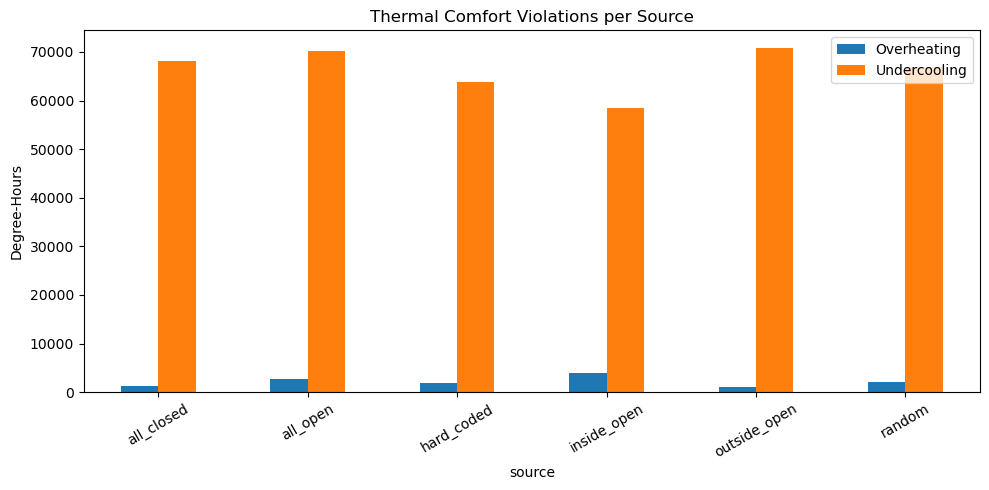

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

T_HIGH = 21
T_LOW = 18

# Overheating (above comfort)
data["overheat"] = (data["operative_temperature"] - T_HIGH).clip(lower=0)

# Undercooling (below comfort)
data["underheat"] = (T_LOW - data["operative_temperature"]).clip(lower=0)

# Aggregate (degree-hours)
ohdh = data.groupby("source")["overheat"].sum() / 12
uhdh = data.groupby("source")["underheat"].sum() / 12

# Combine into one DataFrame
summary = pd.DataFrame({
    "Overheating": ohdh,
    "Undercooling": uhdh
}).sort_index()

# Plot grouped bar
summary.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Degree-Hours")
plt.title("Thermal Comfort Violations per Source")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

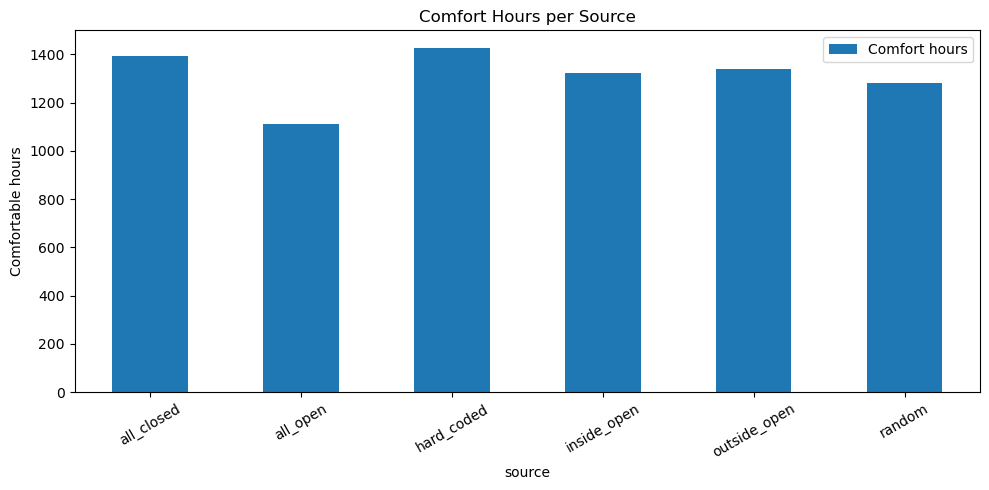

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

T_HIGH = 21
T_LOW = 18

# comfort mask
data["comfort"] = data["operative_temperature"].between(T_LOW, T_HIGH)

# aggregate
comfort_hours = data.groupby("source")["comfort"].sum() / 12

# build clean summary dataframe
summary = pd.DataFrame({
    "Comfort hours": comfort_hours
}).sort_index()

# plot
summary.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Comfortable hours")
plt.title("Comfort Hours per Source")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

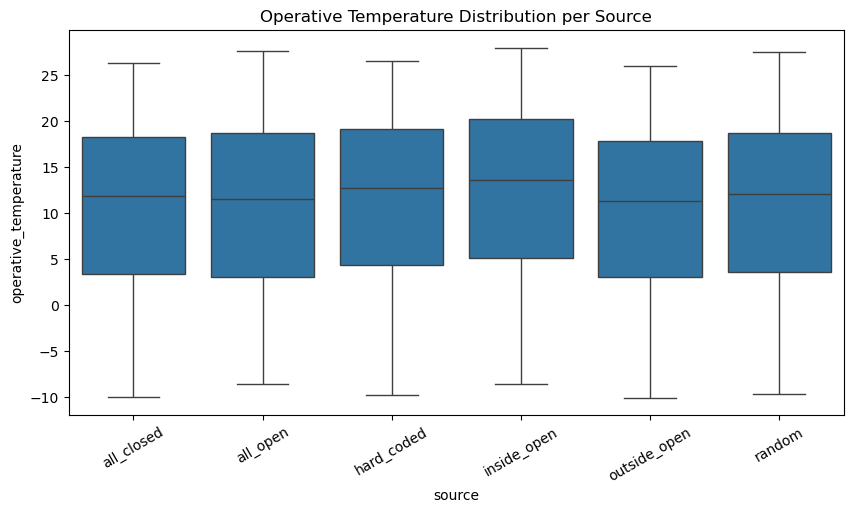

In [51]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data,
    x="source",
    y="operative_temperature"
)

plt.title("Operative Temperature Distribution per Source")
plt.xticks(rotation=30)
plt.show()